# SynPOS: Syntactic Feature Branch for Hindi POS Tagging

Replaces MRL-POS's morphological affix branch with a **local context CNN** branch,
testing whether syntactic inductive bias is more appropriate than morphological
inductive bias for Hindi (fusional) POS tagging.

**Key difference from MRL-POS:**
- MRL-POS: XLM-R + **Akshara affix branch** (BiLSTM + attention) + Dual-Gating Co-Attention + CRF
- SynPOS:  XLM-R + **Local context CNN branch** (multi-scale convolutions) + Dual-Gating Co-Attention + CRF

**Hypothesis:** Hindi POS errors (PROPN/NOUN, ADJ/NOUN) are driven by local syntactic
context (word order, neighboring function words), not morphology. A CNN over the local
window of encoder states should capture this better than affix n-grams.

**Controlled experiment:** Same encoder, same co-attention, same gating, same CRF,
same data, same hyperparameters. Only the feature branch changes.

In [ ]:
# Cell 1: Install dependencies
!pip install -q transformers pytorch-crf seqeval regex conllu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# Cell 2: Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import XLMRobertaModel, XLMRobertaTokenizer
from torchcrf import CRF
from collections import Counter
import numpy as np
import os
import regex

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Cell 2b: Mount Google Drive for persistent checkpoints
try:
    from google.colab import drive
    drive.mount('/content/drive')
    CKPT_DIR = '/content/drive/MyDrive/mrl_pos_checkpoints'
    import os
    os.makedirs(CKPT_DIR, exist_ok=True)
    COLAB = True
    print(f"\u2713 Google Drive mounted. Checkpoints: {CKPT_DIR}")
except:

    COLAB = False
    CKPT_DIR = './'
    print("\u26a0 Not in Colab. Checkpoints will be saved locally.")

Mounted at /content/drive
✓ Google Drive mounted. Checkpoints: /content/drive/MyDrive/mrl_pos_checkpoints


## 1. Local Context CNN Branch

Instead of extracting akshara-level affixes (as in MRL-POS), SynPOS uses **multi-scale
1D convolutions** over the encoder's hidden states to capture local syntactic patterns.

**Intuition:** Hindi POS disambiguation depends on local word order:
- DET before NOUN: `यह` (DET) `लड़का` (NOUN)
- ADP after NOUN: `घर` (NOUN) `से` (ADP)
- ADJ before NOUN: `अच्छी` (ADJ) `किताब` (NOUN)

A CNN with kernels of size 1, 2, 3 captures unigram, bigram, and trigram patterns
in the encoder's representation space — the syntactic equivalent of affix n-grams.

In [ ]:
# Cell 3: Local Context CNN Branch (replaces Akshara splitter + Affix extractor)

class LocalContextBranch(nn.Module):
    """Multi-scale CNN over encoder hidden states for local syntactic features.

    Replaces the affix embedding module from MRL-POS. Instead of extracting
    character/akshara n-grams, we apply 1D convolutions directly over the
    encoder's contextual representations to capture local word-order patterns.
    """

    def __init__(self, input_dim=768, output_dim=768, kernel_sizes=(1, 2, 3)):
        super().__init__()
        self.kernel_sizes = kernel_sizes
        channels_per_kernel = output_dim // len(kernel_sizes)
        self.remainder = output_dim - channels_per_kernel * len(kernel_sizes)

        self.convs = nn.ModuleList()
        for i, ks in enumerate(kernel_sizes):
            out_ch = channels_per_kernel + (1 if i < self.remainder else 0)
            self.convs.append(
                nn.Conv1d(input_dim, out_ch, ks, padding=ks // 2)
            )

        self.norm = nn.LayerNorm(output_dim)
        self.dropout = nn.Dropout(0.1)

    def forward(self, encoder_hidden, attention_mask):
        """
        Args:
            encoder_hidden: (batch, seq_len, input_dim) from XLM-R
            attention_mask:  (batch, seq_len)
        Returns:
            (batch, seq_len, output_dim) local context representation
        """
        # Conv1d expects (batch, channels, seq_len)
        x = encoder_hidden.transpose(1, 2)

        conv_outs = []
        for conv in self.convs:
            c = F.gelu(conv(x))  # (batch, out_channels, seq_len)
            # Trim to match input length (odd kernels with padding=ks//2 are exact,
            # even kernels may add 1 extra)
            c = c[:, :, :encoder_hidden.size(1)]
            conv_outs.append(c)

        # Concat channels: (batch, output_dim, seq_len) -> (batch, seq_len, output_dim)
        h_syn = torch.cat(conv_outs, dim=1).transpose(1, 2)

        # Mask padding positions
        h_syn = h_syn * attention_mask.unsqueeze(-1).float()

        return self.dropout(self.norm(h_syn))


# Demo
branch = LocalContextBranch(input_dim=768, output_dim=768)
dummy_hidden = torch.randn(2, 10, 768)
dummy_mask = torch.ones(2, 10, dtype=torch.long)
out = branch(dummy_hidden, dummy_mask)
print(f"LocalContextBranch output shape: {out.shape}")
print(f"Parameters: {sum(p.numel() for p in branch.parameters()):,}")

LocalContextBranch output shape: torch.Size([2, 10, 768])
Parameters: 1,181,952


## 2. Model Components

Architecture uses the **same** Layer-Wise Attention Pooling and Dual-Gating Co-Attention
from MRL-POS. Only the feature branch input changes:
- MRL-POS feeds **affix embeddings** (from akshara n-grams) into co-attention
- SynPOS feeds **local context CNN output** (from encoder hidden states) into co-attention

In [ ]:
# Cell 4: Model Components (LayerWise Pooling + Dual-Gating — IDENTICAL to MRL-POS)

# Layer-Wise Attention Pooling (Sec 3.2 of MRL-POS paper)
class LayerWiseAttentionPooling(nn.Module):
    def __init__(self, hidden_dim=768, num_layers=12):
        super().__init__()
        self.layer_weights = nn.Linear(hidden_dim, 1)

    def forward(self, all_hidden_states):
        stacked = torch.stack(all_hidden_states[1:], dim=2)
        scores = self.layer_weights(stacked).squeeze(-1)
        alpha = F.softmax(scores, dim=-1)
        return (alpha.unsqueeze(-1) * stacked).sum(dim=2)


# Dual-Gating Co-Attention (Sec 3.4 of MRL-POS paper — IDENTICAL)
class DualGatingCoAttention(nn.Module):
    def __init__(self, hidden_dim=768):
        super().__init__()
        d = hidden_dim
        self.W_a2c = nn.Linear(2 * d, d)
        self.W_c2a = nn.Linear(2 * d, d)
        self.linear_fuse = nn.Linear(2 * d, d)

    def forward(self, H_cw, H_aw):
        concat = torch.cat([H_cw, H_aw], dim=-1)
        g_a2c = torch.sigmoid(self.W_a2c(concat))
        H_cw_gated = g_a2c * H_cw
        g_c2a = torch.sigmoid(self.W_c2a(concat))
        H_aw_gated = g_c2a * H_aw
        fused = torch.cat([H_cw_gated, H_aw_gated], dim=-1)
        return self.linear_fuse(fused)


print("Model components defined (LayerWiseAttentionPooling, DualGatingCoAttention).")
print("Note: AffixEmbeddingModule removed — replaced by LocalContextBranch.")

Model components defined (LayerWiseAttentionPooling, DualGatingCoAttention).
Note: AffixEmbeddingModule removed — replaced by LocalContextBranch.


## 3. SynPOS Model

Same structure as `MRLPOS_Hindi` but with `LocalContextBranch` instead of `AffixEmbeddingModule`.
The forward pass no longer requires `affix_ids` — the syntactic branch operates directly
on the encoder's hidden states.

In [ ]:
# Cell 5: Full SynPOS Model for Hindi

class SynPOS_Hindi(nn.Module):
    """XLM-R + Local Context CNN + Dual-Gating Co-Attention + CRF.

    Drop-in replacement for MRLPOS_Hindi. Same co-attention and gating,
    but the affix branch is replaced with a local context CNN branch.
    No affix extraction or vocabulary needed.
    """
    def __init__(self, num_tags, hidden_dim=768, kernel_sizes=(1, 2, 3)):
        super().__init__()
        self.num_tags = num_tags

        # Encoder (IDENTICAL to MRL-POS)
        self.xlmr = XLMRobertaModel.from_pretrained(
            "xlm-roberta-base", output_hidden_states=True
        )
        self.layer_pooling = LayerWiseAttentionPooling(hidden_dim)

        # Syntactic branch (DIFFERENT — replaces AffixEmbeddingModule)
        self.syn_branch = LocalContextBranch(
            input_dim=hidden_dim, output_dim=hidden_dim,
            kernel_sizes=kernel_sizes,
        )

        # Co-attention + CRF (IDENTICAL to MRL-POS)
        self.co_attention = DualGatingCoAttention(hidden_dim)
        self.classifier = nn.Linear(hidden_dim, num_tags)
        self.crf = CRF(num_tags, batch_first=True)

    def forward(self, input_ids, attention_mask, tags=None):
        # Encoder + layer pooling (IDENTICAL)
        xlmr_out = self.xlmr(input_ids=input_ids, attention_mask=attention_mask)
        H_cw = self.layer_pooling(xlmr_out.hidden_states)

        # Syntactic branch (DIFFERENT — no affix_ids needed)
        H_syn = self.syn_branch(H_cw, attention_mask)

        # Co-attention + gating + CRF (IDENTICAL)
        H_fused = self.co_attention(H_cw, H_syn)
        emissions = self.classifier(H_fused)

        if tags is not None:
            return -self.crf(emissions, tags, mask=attention_mask.bool())
        else:
            return self.crf.decode(emissions, mask=attention_mask.bool())


print("SynPOS_Hindi model defined.")

SynPOS_Hindi model defined.


## 4. Hindi Demo Data

Synthetic Hindi sentences with POS tags (Universal Dependencies tagset).
Replace with the **Hindi HDTB treebank** for real experiments.

In [ ]:
# Cell 6: Hindi tag set and demo data

# Universal Dependencies POS tags (used by Hindi HDTB treebank)
TAG2IDX = {
    "PAD": 0,
    "NOUN": 1, "VERB": 2, "ADJ": 3, "ADV": 4, "ADP": 5,
    "PRON": 6, "DET": 7, "NUM": 8, "CONJ": 9, "PART": 10,
    "AUX": 11, "PUNCT": 12, "PROPN": 13, "SCONJ": 14, "X": 15
}
IDX2TAG = {v: k for k, v in TAG2IDX.items()}
NUM_TAGS = len(TAG2IDX)

# Synthetic Hindi sentences for demo
# Format: ([words], [UD POS tags])
HINDI_DEMO = [
    # "The boy eats food."
    (["\u0932\u0921\u093c\u0915\u093e", "\u0916\u093e\u0928\u093e", "\u0916\u093e\u0924\u093e", "\u0939\u0948", "\u0964"],
     ["NOUN", "NOUN", "VERB", "AUX", "PUNCT"]),

    # "The girl went to school."
    (["\u0932\u0921\u093c\u0915\u0940", "\u0938\u094d\u0915\u0942\u0932", "\u0917\u0908", "\u0964"],
     ["NOUN", "NOUN", "VERB", "PUNCT"]),

    # "Children play in the garden."
    (["\u092c\u091a\u094d\u091a\u094b\u0902", "\u0928\u0947", "\u092c\u0917\u0940\u091a\u0947", "\u092e\u0947\u0902", "\u0916\u0947\u0932\u093e", "\u0964"],
     ["NOUN", "ADP", "NOUN", "ADP", "VERB", "PUNCT"]),

    # "She reads a good book."
    (["\u0935\u0939", "\u0905\u091a\u094d\u091b\u0940", "\u0915\u093f\u0924\u093e\u092c", "\u092a\u0922\u093c\u0924\u0940", "\u0939\u0948", "\u0964"],
     ["PRON", "ADJ", "NOUN", "VERB", "AUX", "PUNCT"]),

    # "Ram went to Delhi yesterday."
    (["\u0930\u093e\u092e", "\u0915\u0932", "\u0926\u093f\u0932\u094d\u0932\u0940", "\u0917\u092f\u093e", "\u0964"],
     ["PROPN", "ADV", "PROPN", "VERB", "PUNCT"]),

    # "I will write a letter."
    (["\u092e\u0948\u0902", "\u092a\u0924\u094d\u0930", "\u0932\u093f\u0916\u0942\u0901\u0917\u093e", "\u0964"],
     ["PRON", "NOUN", "VERB", "PUNCT"]),

    # "Those girls are singing."
    (["\u0935\u0947", "\u0932\u0921\u093c\u0915\u093f\u092f\u093e\u0901", "\u0917\u093e", "\u0930\u0939\u0940", "\u0939\u0948\u0902", "\u0964"],
     ["DET", "NOUN", "VERB", "AUX", "AUX", "PUNCT"]),

    # "He quickly ran home."
    (["\u0935\u0939", "\u0924\u0947\u091c\u093c\u0940", "\u0938\u0947", "\u0918\u0930", "\u092d\u093e\u0917\u093e", "\u0964"],
     ["PRON", "NOUN", "ADP", "NOUN", "VERB", "PUNCT"]),

    # "The big dog sat."
    (["\u092c\u0921\u093c\u093e", "\u0915\u0941\u0924\u094d\u0924\u093e", "\u092c\u0948\u0920\u093e", "\u0964"],
     ["ADJ", "NOUN", "VERB", "PUNCT"]),

    # "We will go together."
    (["\u0939\u092e", "\u0938\u093e\u0925", "\u091a\u0932\u0947\u0902\u0917\u0947", "\u0964"],
     ["PRON", "ADV", "VERB", "PUNCT"]),
]

print(f"Demo sentences: {len(HINDI_DEMO)}")
print(f"Tags: {list(TAG2IDX.keys())}")
print(f"\nSample sentence:")
for w, t in zip(HINDI_DEMO[2][0], HINDI_DEMO[2][1]):
    print(f"  {w:10s} \u2192 {t}")

Demo sentences: 10
Tags: ['PAD', 'NOUN', 'VERB', 'ADJ', 'ADV', 'ADP', 'PRON', 'DET', 'NUM', 'CONJ', 'PART', 'AUX', 'PUNCT', 'PROPN', 'SCONJ', 'X']

Sample sentence:
  बच्चों     → NOUN
  ने         → ADP
  बगीचे      → NOUN
  में        → ADP
  खेला       → VERB
  ।          → PUNCT


In [ ]:
# Cell 7: Dataset class (handles XLM-R subword <-> word alignment)
# CHANGED from MRL-POS: no affix_ids in output, no affix_extractor dependency

class SynPOSDataset(Dataset):
    """POS dataset for SynPOS. No affix extraction needed —
    the syntactic branch operates on encoder hidden states directly."""
    def __init__(self, data, tokenizer, tag2idx, max_len=64):
        self.data = data
        self.tokenizer = tokenizer
        self.tag2idx = tag2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        words, tags = self.data[idx]

        encoding = self.tokenizer(
            words, is_split_into_words=True,
            padding="max_length", truncation=True,
            max_length=self.max_len, return_tensors="pt"
        )

        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)
        word_ids = encoding.word_ids()

        aligned_tags = []
        prev_word_id = None

        for i, wid in enumerate(word_ids):
            if wid is None:
                aligned_tags.append(self.tag2idx["PAD"])
            elif wid != prev_word_id:
                aligned_tags.append(self.tag2idx[tags[wid]])
            else:
                aligned_tags.append(self.tag2idx["PAD"])
            prev_word_id = wid

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "tags": torch.tensor(aligned_tags, dtype=torch.long),
        }


tokenizer = XLMRobertaTokenizer.from_pretrained("xlm-roberta-base")
dataset = SynPOSDataset(HINDI_DEMO, tokenizer, TAG2IDX, max_len=32)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

batch = next(iter(dataloader))
print("Batch shapes:")
for k, v in batch.items():
    print(f"  {k}: {v.shape}")
print("\nNote: No affix_ids — SynPOS branch uses encoder hidden states directly.")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Batch shapes:
  input_ids: torch.Size([4, 32])
  attention_mask: torch.Size([4, 32])
  tags: torch.Size([4, 32])

Note: No affix_ids — SynPOS branch uses encoder hidden states directly.


## 5. Training

In [ ]:
# Cell 8: Instantiate model and optimizer for demo training
model = SynPOS_Hindi(
    num_tags=NUM_TAGS,
).to(device)

optimizer = torch.optim.AdamW([
    {"params": list(model.xlmr.parameters()), "lr": 3e-5},
    {"params": [p for n, p in model.named_parameters()
                if not n.startswith("xlmr.")], "lr": 1e-3},
])

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(f"Num tags: {NUM_TAGS}")

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model parameters: 282,780,209
Num tags: 16


In [ ]:
# Cell 9: Training loop (5 epochs on demo data)

NUM_EPOCHS = 5

# Try loading checkpoint if it exists
ckpt_path = os.path.join(CKPT_DIR, "synpos_hindi_demo_best_cnn.pt")
start_epoch = 0
best_f1_loaded = 0
if os.path.exists(ckpt_path):
    print(f"Loading checkpoint from {ckpt_path}...")
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    start_epoch = ckpt.get('epoch', 0)
    best_f1_loaded = ckpt.get('best_f1', 0)
    print(f"  Resumed from epoch {start_epoch}, Best F1={best_f1_loaded:.4f}")

model.train()
for epoch in range(start_epoch, NUM_EPOCHS):
    total_loss = 0
    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        tags = batch["tags"].to(device)

        optimizer.zero_grad()
        loss = model(input_ids, attention_mask, tags=tags)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {total_loss / len(dataloader):.4f}")

Epoch 1/5 | Loss: 57.5629
Epoch 2/5 | Loss: 22.6591
Epoch 3/5 | Loss: 5.4347
Epoch 4/5 | Loss: 2.4862
Epoch 5/5 | Loss: 1.1350


## 6. Inference

In [ ]:
# Cell 10: Run inference on a test sentence

model.eval()

test_words = ["\u0932\u0921\u093c\u0915\u0940", "\u0905\u091a\u094d\u091b\u0940", "\u0915\u093f\u0924\u093e\u092c", "\u092a\u0922\u093c\u0924\u0940", "\u0939\u0948", "\u0964"]
test_sample = SynPOSDataset(
    [(test_words, ["NOUN"] * len(test_words))],
    tokenizer, TAG2IDX, max_len=32
)[0]

with torch.no_grad():
    input_ids = test_sample["input_ids"].unsqueeze(0).to(device)
    attn_mask = test_sample["attention_mask"].unsqueeze(0).to(device)
    predicted = model(input_ids, attn_mask)[0]

encoding = tokenizer(test_words, is_split_into_words=True,
                     padding="max_length", max_length=32, return_tensors="pt")
word_ids = encoding.word_ids()

print("Predictions:")
print("-" * 35)
prev_wid = None
for i, wid in enumerate(word_ids):
    if wid is not None and wid != prev_wid and i < len(predicted):
        tag = IDX2TAG.get(predicted[i], "?")
        print(f"  {test_words[wid]:12s} \u2192 {tag}")
    prev_wid = wid

Predictions:
-----------------------------------
  लड़की        → NOUN
  अच्छी        → ADJ
  किताब        → NOUN
  पढ़ती        → VERB
  है           → AUX
  ।            → PUNCT


## 7. Visualize Gate Activations

See whether the model leans on **syntactic context** or **global context** for different Hindi word types:
- Postpositions (\u0928\u0947, \u092e\u0947\u0902, \u0938\u0947) \u2014 function words, should lean **global context**
- Nouns before postpositions \u2014 should lean **local syntactic** (neighbor = postposition)
- Verbs \u2014 should use **both** (local context captures auxiliary patterns)

/tmp/ipykernel_2621/1323163345.py:61: UserWarning: Glyph 2348 (\N{DEVANAGARI LETTER BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2621/1323163345.py:61: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_2621/1323163345.py:61: UserWarning: Glyph 2330 (\N{DEVANAGARI LETTER CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2621/1323163345.py:61: UserWarning: Glyph 2381 (\N{DEVANAGARI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2621/1323163345.py:61: UserWarning: Glyph 2379 (\N{DEVANAGARI VOWEL SIGN O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2621/1323163345.py:61: UserWarning: Glyph 2306 (\N{DEVANAGARI SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2621/1323163345.py:61: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layou

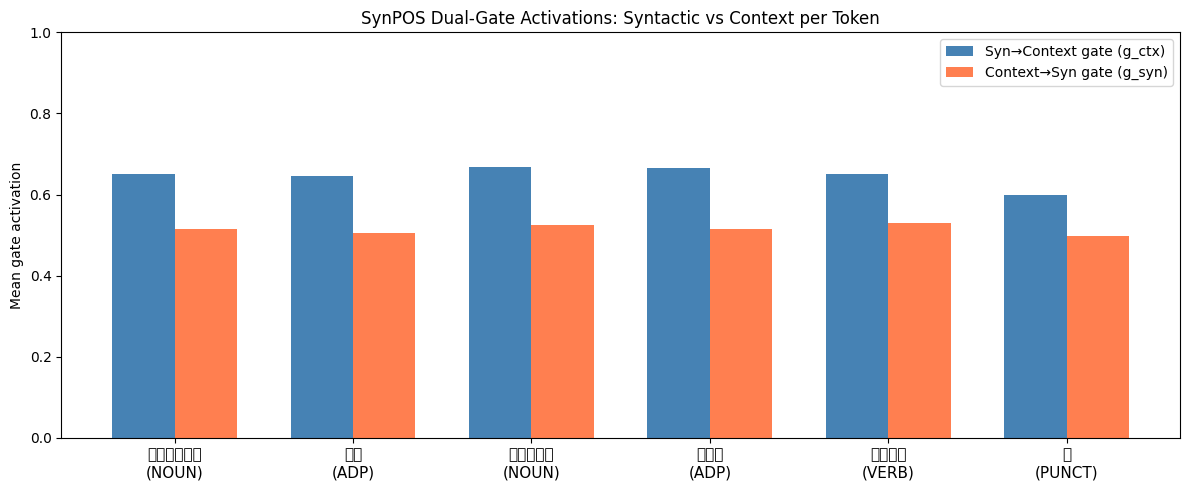

In [ ]:
# Cell 11: Gate activation visualization
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

model.eval()
viz_words = ["\u092c\u091a\u094d\u091a\u094b\u0902", "\u0928\u0947", "\u092c\u0917\u0940\u091a\u0947", "\u092e\u0947\u0902", "\u0916\u0947\u0932\u093e", "\u0964"]
viz_tags  = ["NOUN", "ADP", "NOUN", "ADP", "VERB", "PUNCT"]

viz_sample = SynPOSDataset(
    [(viz_words, viz_tags)],
    tokenizer, TAG2IDX, max_len=32
)[0]

gate_vals = {}
def hook_gates(module, input, output):
    H_cw, H_aw = input
    concat = torch.cat([H_cw, H_aw], dim=-1)
    gate_vals["g_ctx"] = torch.sigmoid(module.W_a2c(concat)).detach().cpu()
    gate_vals["g_syn"] = torch.sigmoid(module.W_c2a(concat)).detach().cpu()

hook = model.co_attention.register_forward_hook(hook_gates)

with torch.no_grad():
    _ = model(
        viz_sample["input_ids"].unsqueeze(0).to(device),
        viz_sample["attention_mask"].unsqueeze(0).to(device),
    )
hook.remove()

# Get word-aligned positions
enc = tokenizer(viz_words, is_split_into_words=True,
                padding="max_length", max_length=32, return_tensors="pt")
wids = enc.word_ids()
word_positions = []
prev = None
for i, wid in enumerate(wids):
    if wid is not None and wid != prev:
        word_positions.append(i)
    prev = wid

ctx_strengths = [gate_vals["g_ctx"][0, p].mean().item() for p in word_positions]
syn_strengths = [gate_vals["g_syn"][0, p].mean().item() for p in word_positions]

# Labels: word + POS
labels = [f"{w}\n({t})" for w, t in zip(viz_words, viz_tags)]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(viz_words))
width = 0.35
ax.bar(x - width/2, ctx_strengths, width,
       label="Syn\u2192Context gate (g_ctx)", color="steelblue")
ax.bar(x + width/2, syn_strengths, width,
       label="Context\u2192Syn gate (g_syn)", color="coral")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Mean gate activation")
ax.set_title("SynPOS Dual-Gate Activations: Syntactic vs Context per Token")
ax.legend(loc="upper right")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 8. Load Real Data: Hindi HDTB Treebank

The [Hindi Universal Dependencies treebank (HDTB)](https://universaldependencies.org/) has ~16K annotated sentences. Here's how to load it for real training.

In [ ]:
# Cell 12: Load Hindi HDTB from Universal Dependencies

import os
import conllu

def download_hdtb():
    """Download Hindi HDTB treebank from Universal Dependencies."""
    ud_url = "https://raw.githubusercontent.com/UniversalDependencies/UD_Hindi-HDTB/master"
    splits = {
        "train": "hi_hdtb-ud-train.conllu",
        "dev":   "hi_hdtb-ud-dev.conllu",
        "test":  "hi_hdtb-ud-test.conllu",
    }
    os.makedirs("hdtb", exist_ok=True)
    for split, fname in splits.items():
        path = f"hdtb/{fname}"
        if not os.path.exists(path):
            print(f"Downloading {split}...")
            !wget -q {ud_url}/{fname} -O {path}
    return splits


def load_conllu(path):
    """Parse a CoNLL-U file into (words, tags) pairs."""
    data = []
    with open(path, 'r') as f:
        for sent in conllu.parse(f.read()):
            words = [tok["form"] for tok in sent]
            tags = [tok["upos"] for tok in sent]
            data.append((words, tags))
    return data


# Download and load
splits = download_hdtb()
train_data = load_conllu(f"hdtb/{splits['train']}")
dev_data   = load_conllu(f"hdtb/{splits['dev']}")
test_data  = load_conllu(f"hdtb/{splits['test']}")

print(f"Train: {len(train_data)} sentences")
print(f"Dev:   {len(dev_data)} sentences")
print(f"Test:  {len(test_data)} sentences")
print(f"\nSample: {train_data[0][0][:6]}")
print(f"Tags:   {train_data[0][1][:6]}")

Train: 13306 sentences
Dev:   1659 sentences
Test:  1684 sentences

Sample: ['यह', 'एशिया', 'की', 'सबसे', 'बड़ी', 'मस्जिदों']
Tags:   ['DET', 'PROPN', 'ADP', 'ADV', 'ADJ', 'NOUN']


In [ ]:
# Cell 13: Full training on HDTB (v3 — cosine schedule, no freeze, lower LR)

from sklearn.metrics import f1_score as sklearn_f1, accuracy_score, classification_report
from transformers import get_cosine_schedule_with_warmup

# Update tag set from actual HDTB data
all_tags = set()
for _, tags in train_data:
    all_tags.update(tags)
REAL_TAG2IDX = {"PAD": 0}
for i, t in enumerate(sorted(all_tags), 1):
    REAL_TAG2IDX[t] = i
REAL_IDX2TAG = {v: k for k, v in REAL_TAG2IDX.items()}
print(f"Tag set ({len(REAL_TAG2IDX)}): {REAL_TAG2IDX}")

# --- Hyperparameters (v3: cosine + lower encoder LR, NO freeze) ---
BATCH_SIZE = 64
MAX_EPOCHS = 30
PATIENCE = 7
ENCODER_LR = 5e-6        # half of v1's 1e-5
HEAD_LR = 5e-4            # halved from 1e-3 — stabilize head too
WARMUP_RATIO = 0.2        # 20% warmup — ~4 epochs in warmup zone

# Create datasets
train_ds = SynPOSDataset(train_data, tokenizer, REAL_TAG2IDX, max_len=128)
dev_ds   = SynPOSDataset(dev_data, tokenizer, REAL_TAG2IDX, max_len=128)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
dev_dl   = DataLoader(dev_ds, batch_size=BATCH_SIZE)

# Model
real_model = SynPOS_Hindi(
    num_tags=len(REAL_TAG2IDX),
).to(device)

total_params = sum(p.numel() for p in real_model.parameters())
print(f"Total parameters: {total_params:,}")

optimizer = torch.optim.AdamW([
    {"params": list(real_model.xlmr.parameters()), "lr": ENCODER_LR},
    {"params": [p for n, p in real_model.named_parameters()
                if not n.startswith("xlmr.")], "lr": HEAD_LR},
], weight_decay=0.01)

# Cosine schedule with 20% warmup
total_steps = len(train_dl) * MAX_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)

print(f"\nTraining steps: {total_steps}, Warmup: {warmup_steps}")
print(f"Encoder LR: {ENCODER_LR}, Head LR: {HEAD_LR}")
print(f"Batch size: {BATCH_SIZE}, Patience: {PATIENCE}")
print(f"Schedule: cosine with 20% warmup, no encoder freeze")

# --- Evaluation function ---
def evaluate(model, dataloader, idx2tag):
    """Compute token-level accuracy and macro F1, excluding PAD tokens."""
    model.eval()
    all_preds = []
    all_golds = []

    with torch.no_grad():
        for batch in dataloader:
            preds = model(
                batch["input_ids"].to(device),
                batch["attention_mask"].to(device),
            )
            tags = batch["tags"]
            mask = batch["attention_mask"]

            for b in range(len(preds)):
                for i, (pred_idx, gold, m) in enumerate(
                    zip(preds[b], tags[b], mask[b])
                ):
                    if m.item() == 1 and gold.item() != 0:
                        all_preds.append(pred_idx)
                        all_golds.append(gold.item())

    acc = accuracy_score(all_golds, all_preds)
    f1 = sklearn_f1(all_golds, all_preds, average="macro", zero_division=0)

    return acc, f1

# Checkpoint (v3 — fresh start)
ckpt_path = f"{CKPT_DIR}/synpos_hindi_v3_best.pt"
start_epoch = 0
best_f1 = 0
best_state = {k: v.cpu().clone() for k, v in real_model.state_dict().items()}

if os.path.exists(ckpt_path):
    print(f"\nLoading checkpoint from {ckpt_path}...")
    ckpt = torch.load(ckpt_path, map_location=device)
    real_model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    start_epoch = ckpt.get('epoch', 0)
    best_f1 = ckpt.get('best_f1', 0)
    best_state = ckpt['model_state_dict']
    for _ in range(start_epoch * len(train_dl)):
        scheduler.step()
    print(f"  Resumed from epoch {start_epoch}, Best F1={best_f1:.4f}")

# --- Training loop ---
no_improve = 0

for epoch in range(start_epoch, MAX_EPOCHS):
    real_model.train()
    total_loss = 0
    for batch in train_dl:
        optimizer.zero_grad()
        loss = real_model(
            batch["input_ids"].to(device),
            batch["attention_mask"].to(device),
            tags=batch["tags"].to(device),
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(real_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_dl)
    acc, f1 = evaluate(real_model, dev_dl, REAL_IDX2TAG)
    current_lr = scheduler.get_last_lr()[0]
    print(f"Epoch {epoch+1:2d} | Loss: {avg_loss:.4f} | "
          f"Dev Acc: {acc:.4f} | Dev Macro-F1: {f1:.4f} | LR: {current_lr:.2e}")

    if f1 > best_f1:
        best_f1 = f1
        no_improve = 0
        best_state = {k: v.cpu().clone() for k, v in real_model.state_dict().items()}
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': best_state,
            'optimizer_state_dict': optimizer.state_dict(),
            'best_f1': best_f1,
        }, ckpt_path)
        print(f"  -> Saved checkpoint (F1={best_f1:.4f})")
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}. Best Macro-F1: {best_f1:.4f}")
            break

# --- Final report on dev set ---
print("\n" + "=" * 50)
print("Final classification report on dev set:")
print("=" * 50)
real_model.load_state_dict(best_state)
real_model.to(device)
real_model.eval()

all_preds, all_golds = [], []
with torch.no_grad():
    for batch in dev_dl:
        preds = real_model(
            batch["input_ids"].to(device),
            batch["attention_mask"].to(device),
        )
        for b in range(len(preds)):
            for pred_idx, gold, m in zip(preds[b], batch["tags"][b], batch["attention_mask"][b]):
                if m.item() == 1 and gold.item() != 0:
                    all_preds.append(REAL_IDX2TAG[pred_idx])
                    all_golds.append(REAL_IDX2TAG[gold.item()])

real_tags = sorted([t for t in REAL_TAG2IDX.keys() if t != "PAD"])
print(classification_report(all_golds, all_preds, labels=real_tags, zero_division=0))

Tag set (17): {'PAD': 0, 'ADJ': 1, 'ADP': 2, 'ADV': 3, 'AUX': 4, 'CCONJ': 5, 'DET': 6, 'INTJ': 7, 'NOUN': 8, 'NUM': 9, 'PART': 10, 'PRON': 11, 'PROPN': 12, 'PUNCT': 13, 'SCONJ': 14, 'VERB': 15, 'X': 16}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters: 282,781,013

Training steps: 6240, Warmup: 1248
Encoder LR: 5e-06, Head LR: 0.0005
Batch size: 64, Patience: 7
Schedule: cosine with 20% warmup, no encoder freeze
Epoch  1 | Loss: 2039.6533 | Dev Acc: 0.9523 | Dev Macro-F1: 0.8105 | LR: 8.33e-07
  -> Saved checkpoint (F1=0.8105)
Epoch  2 | Loss: 176.1598 | Dev Acc: 0.9701 | Dev Macro-F1: 0.9007 | LR: 1.67e-06
  -> Saved checkpoint (F1=0.9007)
Epoch  3 | Loss: 121.6493 | Dev Acc: 0.9753 | Dev Macro-F1: 0.9416 | LR: 2.50e-06
  -> Saved checkpoint (F1=0.9416)
Epoch  4 | Loss: 96.8948 | Dev Acc: 0.9771 | Dev Macro-F1: 0.9280 | LR: 3.33e-06
Epoch  5 | Loss: 81.4063 | Dev Acc: 0.9784 | Dev Macro-F1: 0.9414 | LR: 4.17e-06
Epoch  6 | Loss: 67.9890 | Dev Acc: 0.9789 | Dev Macro-F1: 0.9277 | LR: 5.00e-06
Epoch  7 | Loss: 55.3454 | Dev Acc: 0.9782 | Dev Macro-F1: 0.9188 | LR: 4.98e-06
Epoch  8 | Loss: 44.3754 | Dev Acc: 0.9796 | Dev Macro-F1: 0.9254 | LR: 4.91e-06
Epoch  9 | Loss: 35.1297 | Dev Acc: 0.9800 | Dev Macro-F1: 0.9219

## 9. Summary: SynPOS vs MRL-POS

| Component | MRL-POS (Morphological) | SynPOS (Syntactic) |
|---|---|---|
| **Feature branch** | Akshara n-gram affixes | Local context CNN |
| **Branch input** | Affix vocabulary indices | Encoder hidden states |
| **Preprocessing** | Akshara splitter + freq-filtered vocab | None |
| **Branch architecture** | Embedding + BiLSTM + Attention | Conv1d (kernels 1,2,3) + LayerNorm |
| **Co-attention** | Dual-gating (identical) | Dual-gating (identical) |
| **Encoder** | XLM-RoBERTa-base (identical) | XLM-RoBERTa-base (identical) |
| **CRF** | Identical | Identical |
| **Hyperparameters** | Identical | Identical |
| **Data** | Hindi HDTB (identical) | Hindi HDTB (identical) |

**What this tests:** Whether language-appropriate inductive bias (syntactic for Hindi)
outperforms language-inappropriate bias (morphological, designed for Turkic agglutinative languages).

**Expected outcome:** SynPOS >= MRL-POS on Hindi, because Hindi POS errors (PROPN/NOUN, ADJ/NOUN)
are driven by local word-order patterns, not morphological suffixes.